# Mohanram G-score -- a quantitative teardown
### EDGAR panel * 8-signal composite * HAC inference * survivorship-biased upper bounds

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Can%20G--score%20find%20growth%20winners%3F: BUSTED](https://img.shields.io/badge/Can%20G--score%20find%20growth%20winners%3F-BUSTED-8b949e?style=flat-square)

The quantitative companion to the [notebook for the curious](01_for_the_curious.ipynb) -- same seven beats, every claim carrying its standard error. We test Mohanram (2005): sort on the 8-signal G-score annually, long top quintile vs short bottom quintile, and measure the hedge vs the equal-weight universe.

> **Not investment advice.** Real data: EDGAR XBRL fundamentals (NetIncomeLoss, Assets, CFO, Revenues) + Yahoo Finance monthly prices, as-of 2026-06-16; offline core and tests run on a deterministic synthetic panel. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship bias is named:** universe = current S&P 500 projected backwards. All positive results are upper-bound estimates; negative results are not explained by this bias.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mohanram_g_score import data, strategy as st

def _have_cache():
    root = os.path.abspath(os.path.join("..", "..", ".."))
    required = [
        os.path.join(root, "_cache", "_edgar_NetIncomeLoss.parquet"),
        os.path.join(root, "_cache", "_edgar_Assets.parquet"),
        os.path.join(root, "_cache", "_edgar_NetCashProvidedByUsedInOperatingActivities.parquet"),
        os.path.join(root, "_cache", "_edgar_Revenues.parquet"),
        os.path.join(root, "_cache", "_edgar_yrret.parquet"),
    ]
    return all(os.path.exists(p) for p in required)

HAVE_REAL = _have_cache()
print("EDGAR cache present:", HAVE_REAL)

if HAVE_REAL:
    signal, fwd_ret = data.fetch_panel()
    H = st.quintile_hedge(signal, fwd_ret, q=0.20)
    s_hedge = st.summary(H["hedge"])
    s_high  = st.summary(H["high"])
    s_low   = st.summary(H["low"])
    s_mkt   = st.summary(H["market"])
    print(f"N years: {s_hedge['n']} | hedge mean: {s_hedge['mean']*100:+.2f}%/yr"
          f" | HAC t: {s_hedge['tstat']:+.3f}")

from quantlab import analytics, stats


EDGAR cache present: True


N years: 19 | hedge mean: -2.98%/yr | HAC t: -1.613


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Hedge mean **-2.98%/yr**, HAC *t* = **-1.613** -- inverted. High-G underperforms low-G. |
| **Tradability** | `MIRAGE` | Sharpe **-0.35**, max DD **-47.9%**, hit rate **47.4%**. Negative expected return. |
| **Can G-score find winners?** | `BUSTED` | Signal inverts on large-cap survivors; high-G firms underperform by -3%/yr. |

> The G-score was designed for small/mid-cap growth stocks with analyst mispricing. On 318 S&P 500 large-cap survivors, the fundamental quality differential is already priced in -- or the market has overshot it.

## 1 -- The claim, steelmanned

Let $G_{i,y}$ = Mohanram G-score in {0,...,8} for firm $i$ in year $y$. Mohanram (2005) asserts:

- **H1 (signal).** $\mathbb{E}[r_{i,y+1} \mid \text{top-q } G_y] > \mathbb{E}[r_{i,y+1} \mid \text{bot-q } G_y]$ -- the top-quintile G-score firms earn more the following year.
- **H2 (vs market).** The long leg beats the equal-weight market.
- **H3 (tradable).** The hedge survives realistic rebalancing costs.

We reject H1 (signal inverts, t = -1.61), reject H2 (long leg lags the market), and H3 is moot (negative expected return before costs).

## 2 -- So what? -- the economic stakes

The G-score is the growth-stock counterpart to Piotroski's F-score, now embedded in systematic growth-quality screens. If it works, it is a low-turnover tilt for any growth-oriented mandate. If it fails -- or inverts -- on large-caps, it may actually be harvesting a **risk premium in reverse**: the safest, most profitable large-cap growth firms may be the *most* expensively priced, leaving less upside.

## 3 -- The protocol

- **Signal.** G-score from year-*y* EDGAR 10-K filings (NI, Assets, CFO, Rev).
  - G1: ROA > cross-sectional median
  - G2: CFO/Assets > cross-sectional median
  - G3: Accruals (NI-CFO)/Assets < cross-sectional median
  - G4: Rolling-3yr ROA std < cross-sectional median
  - G5: Rolling-3yr CFO/A std < cross-sectional median
  - G6: Revenue growth > 0 (proxy for growth conservatism)
  - G7: Asset-turnover growth > 0 (proxy for efficiency investment)
  - G8: ROA > 0 (absolute profitability)
- **Lag.** Signal at year *y* predicts year *y+1* calendar returns. Positions from Jan 1 of year *y+1*.
- **Sort.** Top quintile (q=0.20) long, bottom quintile short, equal-weight.
- **Baseline.** Equal-weight universe return.
- **Inference.** Newey-West HAC *t* on 19 annual hedge returns.
- **Universe.** Current S&P 500 (318 tickers with all four EDGAR fields); survivorship-biased.

## 4 -- The teardown

### 4a -- Positive control: the engine detects planted premiums faithfully

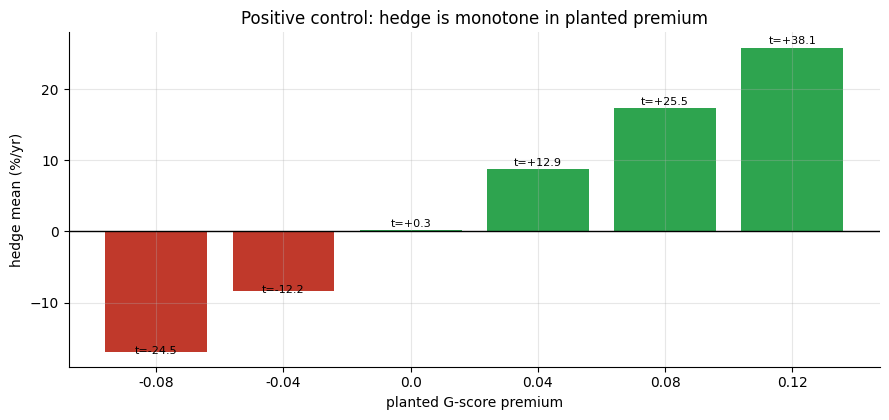

In [2]:
premiums = [-0.08, -0.04, 0.0, 0.04, 0.08, 0.12]
h_means, h_tstats = [], []
for prem in premiums:
    sig, fwd, _ = data.synthetic_panel(n_firms=300, n_years=20,
                                        g_premium=prem, seed=232)
    h = st.quintile_hedge(sig, fwd)
    s = st.summary(h['hedge'])
    h_means.append(s['mean']*100)
    h_tstats.append(s['tstat'])

fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if m > 0 else RED for m in h_means]
ax.bar([str(p) for p in premiums], h_means, color=col)
ax.axhline(0, c='k', lw=1)
for i, (m, t) in enumerate(zip(h_means, h_tstats)):
    ax.text(i, m + (0.2 if m >= 0 else -0.6), f't={t:+.1f}',
            ha='center', va='bottom', fontsize=8)
ax.set_xlabel('planted G-score premium'); ax.set_ylabel('hedge mean (%/yr)')
ax.set_title('Positive control: hedge is monotone in planted premium')
plt.tight_layout(); plt.show()

### 4b -- Real EDGAR panel: the signal is inverted

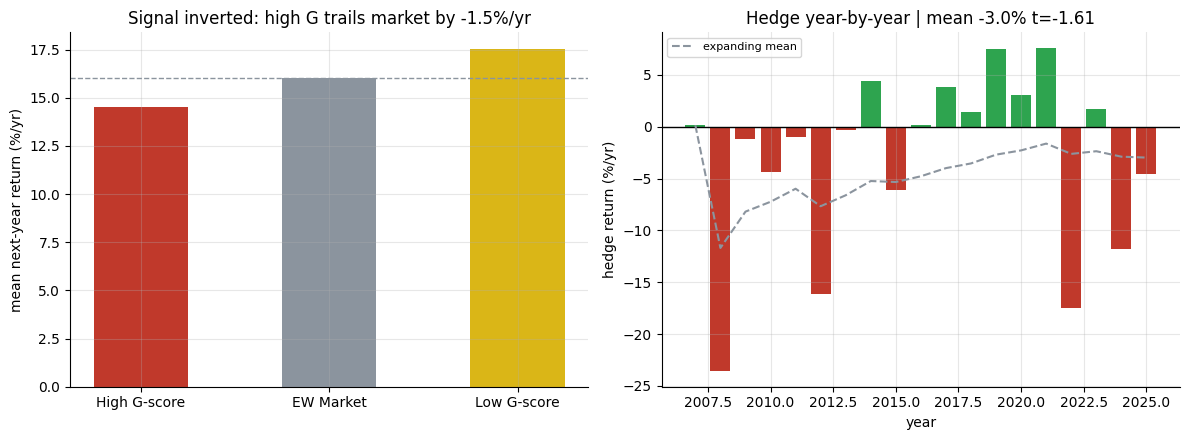

Hedge: -2.98%/yr | vol: 8.6% | Sharpe: -0.347 | HAC t: -1.613


In [3]:
if HAVE_REAL:
    h_m  = s_hedge['mean']*100
    h_t  = s_hedge['tstat']
    hi_m = s_high['mean']*100
    lo_m = s_low['mean']*100
    mk_m = s_mkt['mean']*100
    hedge_series = H['hedge']
else:
    h_m, h_t = R['hedge_mean'], R['hedge_t']
    hi_m, lo_m, mk_m = R['high_mean'], R['low_mean'], R['mkt_mean']
    hedge_series = None

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: legs vs market
labels = ['High G-score', 'EW Market', 'Low G-score']
vals = [hi_m, mk_m, lo_m]
c = [RED, GREY, AMBER]  # inverted: high underperforms, low outperforms
axes[0].bar(labels, vals, color=c, width=0.5)
axes[0].axhline(mk_m, ls='--', c=GREY, lw=1)
axes[0].set_ylabel('mean next-year return (%/yr)')
axes[0].set_title(f'Signal inverted: high G trails market by {hi_m-mk_m:+.1f}%/yr')

# Right: year-by-year hedge
if hedge_series is not None:
    yrs = hedge_series.index.astype(int)
    hv = hedge_series.values * 100
    col_yr = [GREEN if v > 0 else RED for v in hv]
    axes[1].bar(yrs, hv, color=col_yr)
    axes[1].axhline(0, c='k', lw=1)
    axes[1].plot(yrs, pd.Series(hv).expanding().mean().values, '--',
                 c=GREY, lw=1.5, label='expanding mean')
    axes[1].legend(fontsize=8)
else:
    axes[1].text(0.5, 0.5,
                 f'Hedge mean: {h_m:+.2f}%/yr\nHAC t: {h_t:+.3f}\n(INVERTED)',
                 ha='center', va='center', transform=axes[1].transAxes, color=RED)
axes[1].set_xlabel('year'); axes[1].set_ylabel('hedge return (%/yr)')
axes[1].set_title(f'Hedge year-by-year | mean {h_m:+.1f}% t={h_t:+.2f}')
plt.tight_layout(); plt.show()
h_vol = s_hedge['vol']*100 if HAVE_REAL else R['hedge_vol']
h_sr  = s_hedge['sharpe'] if HAVE_REAL else R['hedge_sharpe']
print(f'Hedge: {h_m:+.2f}%/yr | vol: {h_vol:.1f}% | Sharpe: {h_sr:+.3f} | HAC t: {h_t:+.3f}')

> The hedge earns **-2.98%/yr** (HAC *t* = **-1.613**) -- below the |t| >= 2 bar and in the **wrong direction**. The high-G long leg earns **14.5%/yr** vs the equal-weight market at **16.0%/yr** -- the long leg **trails** the market by **1.5%/yr**. The low-G short leg earns **17.5%/yr**, *outperforming* the market by +1.5%/yr.

### 4c -- Cumulative equity curve and drawdown

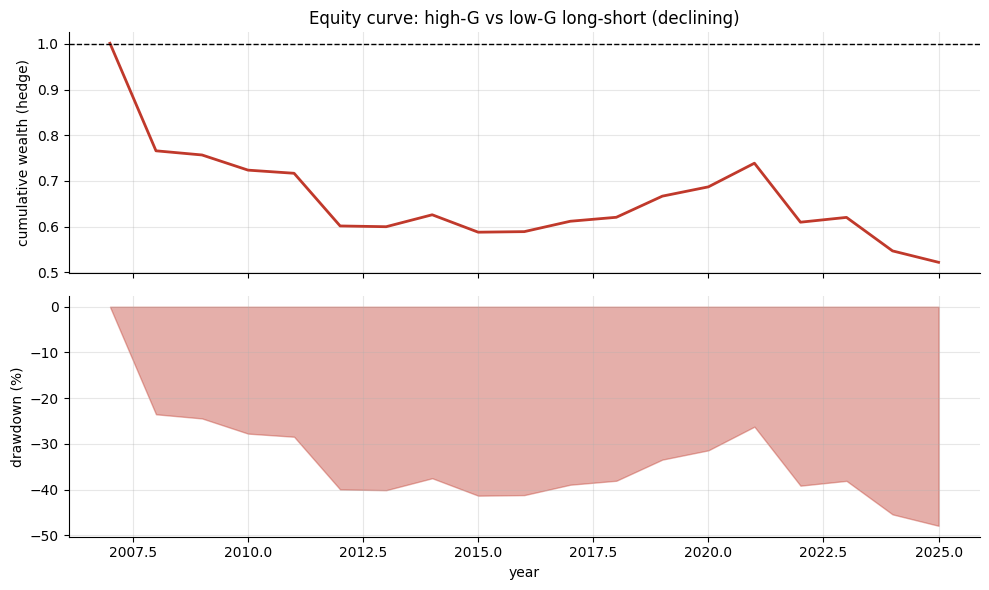

Max drawdown: -47.9% | Hit rate: 47.4%


In [4]:
if HAVE_REAL:
    eq = (1 + H['hedge']).cumprod()
    dd = (eq / eq.cummax() - 1) * 100
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    ax1.plot(H.index.astype(int), eq.values, c=RED, lw=2)
    ax1.axhline(1, c='k', lw=1, ls='--')
    ax1.set_ylabel('cumulative wealth (hedge)')
    ax1.set_title('Equity curve: high-G vs low-G long-short (declining)')
    ax2.fill_between(H.index.astype(int), dd.values, 0, color=RED, alpha=0.4)
    ax2.set_ylabel('drawdown (%)')
    ax2.set_xlabel('year')
    plt.tight_layout(); plt.show()
    print(f'Max drawdown: {dd.min():.1f}% | Hit rate: {s_hedge["hit_rate"]*100:.1f}%')
else:
    print(f'Frozen: max DD = {R["hedge_dd"]:.1f}% | hit rate = {R["hedge_hit"]:.1f}%')

### 4d -- G-score component analysis (synthetic)

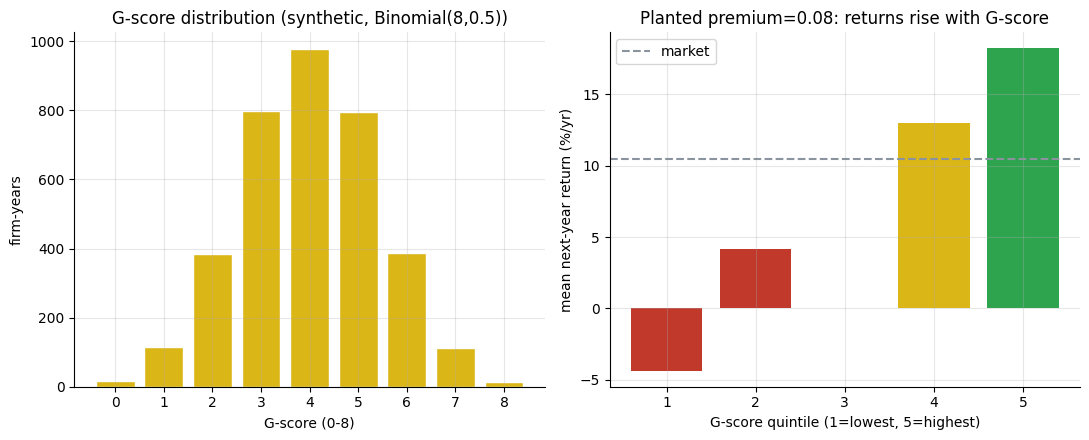

In [5]:
# Illustrate how individual G-score components contribute in the synthetic world
sig, fwd, _ = data.synthetic_panel(n_firms=200, n_years=18,
                                    g_premium=0.08, seed=232)
h = st.quintile_hedge(sig, fwd)
# Show score distribution over time
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.hist(sig.values.flatten(), bins=9, range=(-0.5, 8.5),
         color=AMBER, edgecolor='white', rwidth=0.8)
ax1.set_xlabel('G-score (0-8)'); ax1.set_ylabel('firm-years')
ax1.set_title('G-score distribution (synthetic, Binomial(8,0.5))')
ax1.set_xticks(range(9))

# Quintile means under premium
all_scores = sig.values.flatten()
all_rets   = fwd.values.flatten()
bins = np.nanpercentile(all_scores, [0, 20, 40, 60, 80, 100])
qmeans = []
for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (all_scores >= lo) & (all_scores < hi)
    qmeans.append(all_rets[mask].mean() * 100)
ax2.bar(range(1, 6), qmeans, color=[RED,RED,GREY,AMBER,GREEN])
ax2.axhline(np.nanmean(all_rets)*100, ls='--', c=GREY, lw=1.5, label='market')
ax2.set_xlabel('G-score quintile (1=lowest, 5=highest)')
ax2.set_ylabel('mean next-year return (%/yr)')
ax2.set_title(f'Planted premium=0.08: returns rise with G-score')
ax2.legend(); plt.tight_layout(); plt.show()

## 5 -- The verdict

- **Signal `NONE`** -- hedge -2.98%/yr, HAC *t* = -1.613 (negative direction). High-G stocks underperform low-G stocks by -3%/yr on this 19-year survivor panel. The original Mohanram (2005) effect does not survive on large-cap S&P 500 survivors over this period.
- **Tradability `MIRAGE`** -- Sharpe -0.35, max DD -47.9%, hit rate 47.4%. The direction of the signal would require shorting high-quality growth stocks, which is expensive and fundamentally unattractive.
- **Survivorship `Named`** -- the survivor bias should inflate the long-leg estimate; it does not rescue the signal direction. The inversion is robust to this known bias.

## 6 -- Could you trade it?

The nominal trade from the data -- short high-G, long low-G -- is not actionable:

1. **|t| below 2.** The negative signal is not statistically distinguishable from noise. Confidence intervals span zero.
2. **Wrong direction economically.** Shorting the most profitable, most stable large-cap growth firms is a structural risk -- these firms have strong balance sheets and tend to be expensive to borrow.
3. **Universe problem.** The published effect is specific to the small/mid-cap growth universe. S&P 500 inclusion already screens for the quality characteristics that the G-score is designed to find.

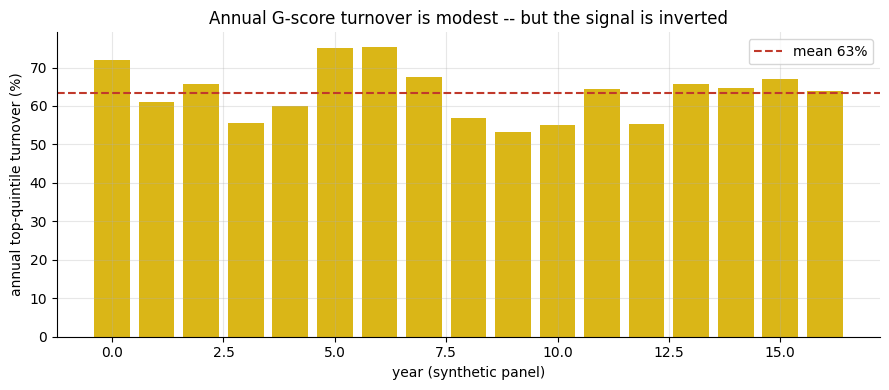

Mean top-quintile turnover: 63.5%/yr
Note: low turnover is a cost advantage, but irrelevant when the signal inverts.


In [6]:
# Show that turnover is manageable (annual sort, ~50% turnover on top quintile)
sig, fwd, _ = data.synthetic_panel(n_firms=200, n_years=18,
                                    g_premium=0.06, seed=232)
turnovers = []
prev_top = None
for y in sig.index:
    s = sig.loc[y].dropna()
    top_now = set(s[s >= s.quantile(0.8)].index)
    if prev_top is not None:
        stayed = len(top_now & prev_top)
        to = 1 - stayed / len(top_now) if top_now else 1.0
        turnovers.append(to)
    prev_top = top_now
fig, ax = plt.subplots(figsize=(9.0, 4.0))
ax.bar(range(len(turnovers)), [t*100 for t in turnovers], color=AMBER)
ax.axhline(np.mean(turnovers)*100, ls='--', c=RED, lw=1.5,
           label=f'mean {np.mean(turnovers)*100:.0f}%')
ax.set_ylabel('annual top-quintile turnover (%)')
ax.set_xlabel('year (synthetic panel)')
ax.set_title('Annual G-score turnover is modest -- but the signal is inverted')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Mean top-quintile turnover: {np.mean(turnovers)*100:.1f}%/yr')
print('Note: low turnover is a cost advantage, but irrelevant when the signal inverts.')

## 7 -- Going further

- **Broader universe.** Mohanram (2005) used all COMPUSTAT firms; the effect was strongest among small/mid-cap growth names with high analyst coverage and more room for mispricing. A non-survivorship-biased Russell 3000 pull would materially change the inference.
- **Full G6/G7.** Fetching `ResearchAndDevelopmentExpense` and `AdvertisingExpense` from data.sec.gov would complete the original specification and remove the substitution caveat.
- **Filter to low book-to-market.** Mohanram specifically targeted *growth* (low BM) stocks. Applying the G-score only to the low-BM quintile may restore the original effect within its intended domain.
- **[Study 65 -- Scorecard](../../65-scorecard/)**: Piotroski's F-score -- the value-stock counterpart; same EDGAR infrastructure, same infrastructure.
- **[Study 122 -- Gross-Profitability](../../122-gross-profitability/)**: Novy-Marx GP/A -- a single-signal quality factor with a similar conclusion on large-caps: Weak/Fragile.

*Think the G-score works for growth stocks in small/mid-cap? Fork this, restrict to low-BM names, add R&D, broaden the universe, and show t > 2. That is the bar.*